## CARGAR LIBRERÍAS

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

## CARGAR DATOS

In [2]:
contract = pd.read_csv(r'C:\Users\User-L\Desktop\Cientifico de datos-preparacion\Sprint 19 Final-Proyect\Datasets\contract.csv')
personal = pd.read_csv(r'C:\Users\User-L\Desktop\Cientifico de datos-preparacion\Sprint 19 Final-Proyect\Datasets\personal.csv')
internet = pd.read_csv(r'C:\Users\User-L\Desktop\Cientifico de datos-preparacion\Sprint 19 Final-Proyect\Datasets\internet.csv')
phone = pd.read_csv(r'C:\Users\User-L\Desktop\Cientifico de datos-preparacion\Sprint 19 Final-Proyect\Datasets\phone.csv')

## INFORMACION GENERAL DE LOS DATOS

In [3]:
contract.info()
print()
print()
personal.info()
print()
print()
internet.info()
print()
print()
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4  

In [4]:
print(contract.shape)
print(personal.shape)
print(internet.shape)
print(phone.shape)

(7043, 8)
(7043, 5)
(5517, 8)
(6361, 2)


## UNION DE LOS DATASETS

In [5]:
merged = contract.merge(personal, on='customerID', how='left') \
             .merge(internet, on='customerID', how='left') \
             .merge(phone, on='customerID', how='left')

print(merged.shape)
merged.head()

(7043, 20)


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No


## INFORMACION GENERAL DEL DATA SET NUEVO

In [6]:
merged.info()
merged.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   5517 non-null   object 
 13  OnlineSecurity    5517 non-null   object 
 14  OnlineBackup      5517 non-null   object 
 15  DeviceProtection  5517 non-null   object 
 16  TechSupport       5517 non-null   object 


,MonthlyCharges,SeniorCitizen
count,7043.000000,7043.000000
mean,64.761692,0.162147
std,30.090047,0.368612
min,18.250000,0.000000
25%,35.500000,0.000000
50%,70.350000,0.000000
75%,89.850000,0.000000
max,118.750000,1.000000


## CREACION DE UNA NUEVA COLUMNA Y VERIFICACION DE DATOS

In [7]:
merged['churn'] = merged['EndDate'].apply(lambda x: 0 if x == 'No' else 1)

merged['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [8]:
merged.isnull().sum().sort_values(ascending=False)

TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
DeviceProtection    1526
InternetService     1526
OnlineBackup        1526
OnlineSecurity      1526
MultipleLines        682
PaperlessBilling       0
customerID             0
Type                   0
EndDate                0
BeginDate              0
Dependents             0
Partner                0
SeniorCitizen          0
gender                 0
MonthlyCharges         0
TotalCharges           0
PaymentMethod          0
churn                  0
dtype: int64

## EVALUACION Y DISTRIBUCION DE LAS VARIABLES

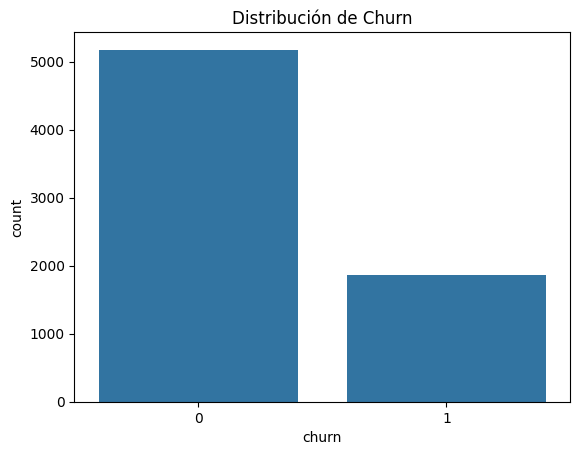

In [9]:
sns.countplot(x='churn', data=merged)
plt.title('Distribución de Churn')
plt.show()

In [10]:
merged['churn'].value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

## VARIABLES CATEGORICAS 

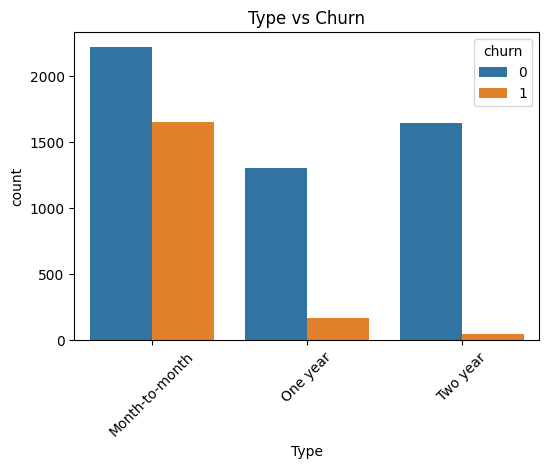

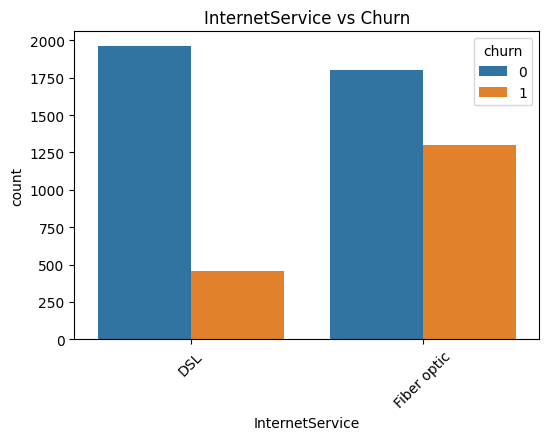

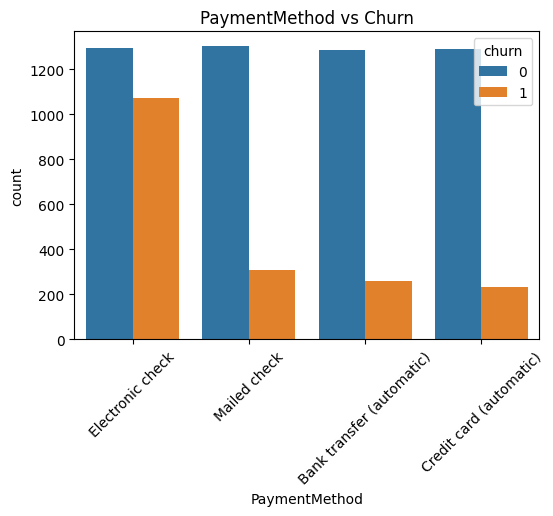

In [11]:
categorical_cols = ['Type', 'InternetService', 'PaymentMethod']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='churn', data=merged)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Churn')
    plt.show()

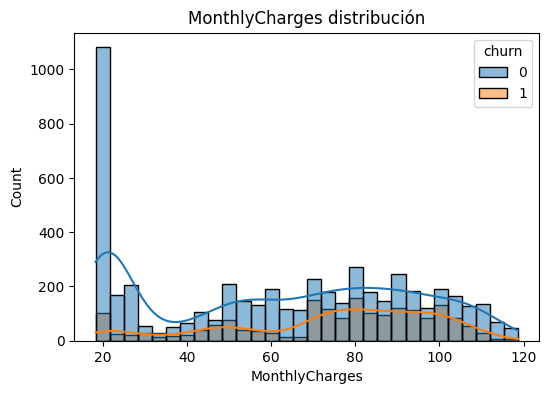

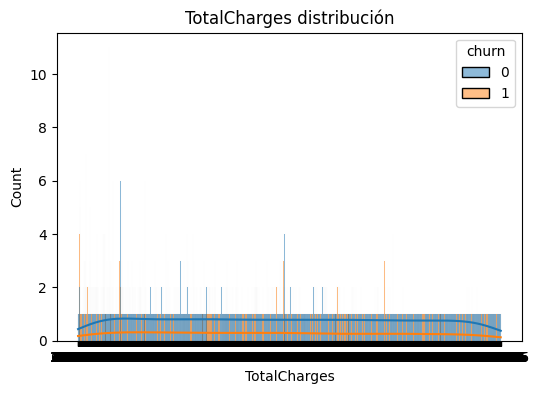

In [12]:
numerical_cols = ['MonthlyCharges', 'TotalCharges']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=merged, x=col, hue='churn', bins=30, kde=True)
    plt.title(f'{col} distribución')
    plt.show()

## LIMPIEZA GENERAL

In [13]:
merged['TotalCharges'] = pd.to_numeric(merged['TotalCharges'], errors='coerce')

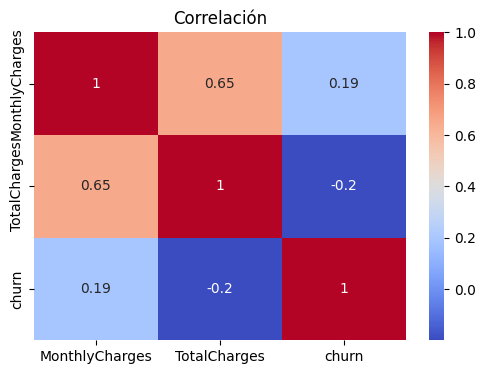

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(merged[['MonthlyCharges', 'TotalCharges', 'churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlación')
plt.show()

## PLAN DE TRABAJO.

 1. Integración y limpieza de datos

Unir los datasets mediante customerID, verificar valores faltantes, tipos de datos y consistencia. Crear una variable objetivo clara (churn).

 2. Análisis exploratorio de datos (EDA)

Explorar distribución de variables, analizar correlaciones y detectar desbalance de clases. Identificar variables relevantes para la cancelación.

 3. Preprocesamiento y feature engineering

Codificar variables categóricas, transformar fechas (ej: duración del contrato), escalar datos si es necesario y preparar dataset para modelado.

 4. Entrenamiento de modelos

Entrenar varios modelos (Dummy, Logistic Regression, Random Forest / Gradient Boosting) y comparar su desempeño.

 5. Evaluación y selección del modelo

Evaluar con métricas adecuadas (F1, ROC-AUC), analizar errores y seleccionar el mejor modelo. Interpretar resultados y variables más importantes.